
DATASET
Dataset shape: (5000, 194)

First rows:
         window_id  label  s1_t0_l5_g0.5_mean  s1_t0_l5_g0.5_std  \
0  14_023_2_0093_1      0           742.57970          294.25012   
1  14_023_2_0093_2      0           770.61770          282.82352   
2  14_023_2_0093_3      0           756.72955          297.86075   
3  14_023_2_0093_4      0           728.27220          286.57297   
4  14_023_2_0093_5      0           759.08390          220.56987   

   s1_t0_l5_g0.5_energy  s1_t0_l5_g0.5_entropy  s1_t0_l5_g0.5_skew  \
0          4.083249e+09              12.643544           -0.072581   
1          4.312581e+09              12.643231           -0.275491   
2          4.232708e+09              12.643231           -0.360157   
3          3.920028e+09              12.643544            0.031978   
4          3.999101e+09              12.643231           -0.222613   

   s1_t0_l5_g0.5_kurtosis  s1_t0_l5_g1.0_mean  s1_t0_l5_g1.0_std  ...  \
0               -1.108089           371.24634   

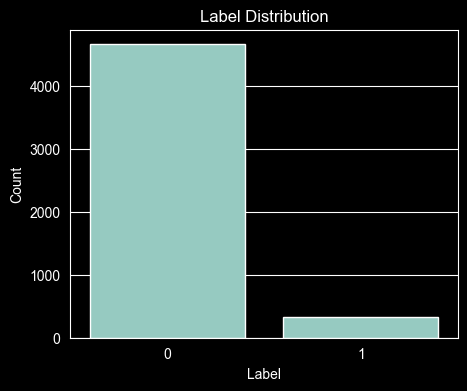


0 = Healthy
1 = Stenosis

FEATURES
Total samples : 5000
Total features: 192

CHECKING NaNs
Total NaNs: 0

TRAIN / TEST
Train samples: 4000
Test samples : 1000

TRAINING RANDOM FOREST
Training completed.

EVALUATION
Accuracy : 0.9390
Precision: 0.8571
Recall   : 0.0909
F1-score : 0.1644
ROC-AUC  : 0.8963

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       934
           1       0.86      0.09      0.16        66

    accuracy                           0.94      1000
   macro avg       0.90      0.54      0.57      1000
weighted avg       0.93      0.94      0.92      1000


CONFUSION MATRIX


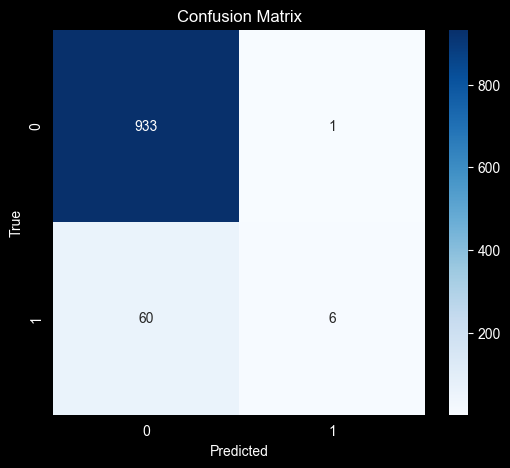


ROC CURVE


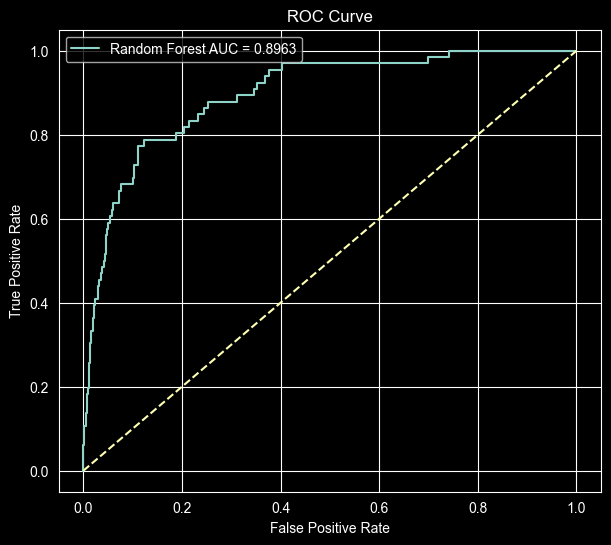


FEATURE IMPORTANCE

TOP 20 FEATURES:

                        feature  importance
85        s1_t2.36_l10_g0.5_std    0.017859
79         s1_t2.36_l5_g1.0_std    0.016735
91        s1_t2.36_l10_g1.0_std    0.016407
73         s1_t2.36_l5_g0.5_std    0.016171
19           s1_t0_l10_g1.0_std    0.015552
7             s1_t0_l5_g1.0_std    0.013758
136      s3_t0.79_l10_g0.5_skew    0.013735
43        s1_t0.79_l10_g1.0_std    0.013593
173   s3_t2.36_l5_g0.5_kurtosis    0.013434
67        s1_t1.57_l10_g1.0_std    0.013413
187       s3_t2.36_l10_g1.0_std    0.012948
163       s3_t1.57_l10_g1.0_std    0.012499
1             s1_t0_l5_g0.5_std    0.011949
31         s1_t0.79_l5_g1.0_std    0.011898
157       s3_t1.57_l10_g0.5_std    0.011797
145        s3_t1.57_l5_g0.5_std    0.011637
137  s3_t0.79_l10_g0.5_kurtosis    0.011626
115          s3_t0_l10_g1.0_std    0.011609
13           s1_t0_l10_g0.5_std    0.011467
55         s1_t1.57_l5_g1.0_std    0.010959


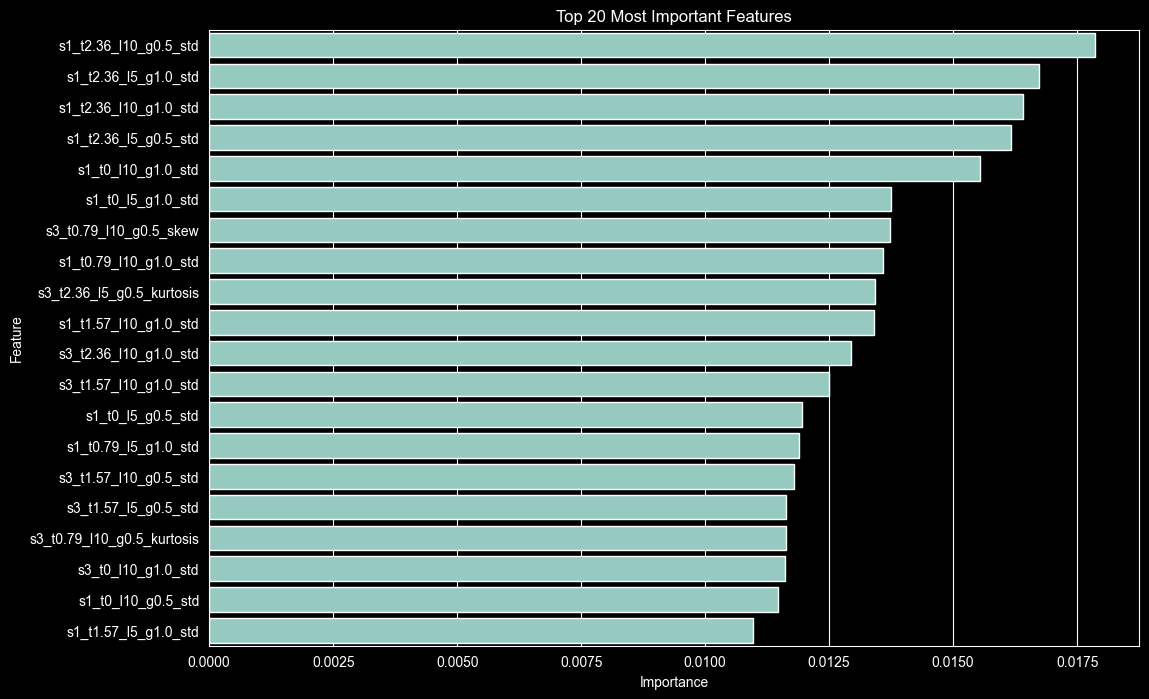


Feature importance saved to feature_importance.csv

Model saved to stenosis_random_forest.pkl

FINAL SUMMARY
Accuracy : 0.9390
Precision: 0.8571
Recall   : 0.0909
F1-score : 0.1644
ROC-AUC  : 0.8963

DONE.


In [1]:
# ============================================================
# STENOSIS RECOGNITION - RANDOM FOREST
# Binary Classification:
# 0 = Healthy
# 1 = Stenosis
# ============================================================

# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# ============================================================
# CONFIG
# ============================================================

CSV_PATH = "stenosis_windows_gabor_features.csv"

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(CSV_PATH)

print("\n================================================")
print("DATASET")
print("================================================")

print(f"Dataset shape: {df.shape}")

print("\nFirst rows:")
print(df.head())

# ============================================================
# LABEL DISTRIBUTION
# ============================================================

print("\n================================================")
print("LABEL DISTRIBUTION")
print("================================================")

print(df['label'].value_counts())

print("\nNormalized distribution:")
print(df['label'].value_counts(normalize=True))

plt.figure(figsize=(5,4))

sns.countplot(data=df, x='label')

plt.title("Label Distribution")

plt.xlabel("Label")

plt.ylabel("Count")

plt.show()

print("\n0 = Healthy")
print("1 = Stenosis")

# ============================================================
# FEATURES / LABELS
# ============================================================

X = df.drop(columns=['window_id', 'label'])

y = df['label']

print("\n================================================")
print("FEATURES")
print("================================================")

print(f"Total samples : {X.shape[0]}")
print(f"Total features: {X.shape[1]}")

# ============================================================
# CHECK NaNs
# ============================================================

print("\n================================================")
print("CHECKING NaNs")
print("================================================")

nan_count = X.isnull().sum().sum()

print(f"Total NaNs: {nan_count}")

if nan_count > 0:

    print("Replacing NaNs with 0...")

    X = X.fillna(0)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    stratify=y,

    random_state=42
)

print("\n================================================")
print("TRAIN / TEST")
print("================================================")

print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples : {X_test.shape[0]}")

# ============================================================
# RANDOM FOREST MODEL
# ============================================================

print("\n================================================")
print("TRAINING RANDOM FOREST")
print("================================================")

rf_model = RandomForestClassifier(

    n_estimators=500,

    max_depth=20,

    min_samples_split=5,

    min_samples_leaf=2,

    class_weight='balanced',

    random_state=42,

    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Training completed.")

# ============================================================
# PREDICTIONS
# ============================================================

y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)[:,1]

# ============================================================
# METRICS
# ============================================================

print("\n================================================")
print("EVALUATION")
print("================================================")

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1-score : {f1:.4f}")

print(f"ROC-AUC  : {roc_auc:.4f}")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n================================================")
print("CLASSIFICATION REPORT")
print("================================================")

print(classification_report(y_test, y_pred))

# ============================================================
# CONFUSION MATRIX
# ============================================================

print("\n================================================")
print("CONFUSION MATRIX")
print("================================================")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("True")

plt.show()

# ============================================================
# ROC CURVE
# ============================================================

print("\n================================================")
print("ROC CURVE")
print("================================================")

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(

    fpr,
    tpr,

    label=f"Random Forest AUC = {roc_auc:.4f}"
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

print("\n================================================")
print("FEATURE IMPORTANCE")
print("================================================")

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({

    'feature': X.columns,

    'importance': importances
})

feature_importance_df = feature_importance_df.sort_values(

    by='importance',

    ascending=False
)

print("\nTOP 20 FEATURES:\n")

print(feature_importance_df.head(20))

# ============================================================
# PLOT TOP FEATURES
# ============================================================

top_features = feature_importance_df.head(20)

plt.figure(figsize=(12,8))

sns.barplot(

    data=top_features,

    x='importance',

    y='feature'
)

plt.title("Top 20 Most Important Features")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()

# ============================================================
# OPTIONAL: SAVE FEATURE IMPORTANCE
# ============================================================

feature_importance_df.to_csv(

    "feature_importance.csv",

    index=False
)

print("\nFeature importance saved to feature_importance.csv")

# ============================================================
# OPTIONAL: SAVE MODEL
# ============================================================

import joblib

joblib.dump(

    rf_model,

    "stenosis_random_forest.pkl"
)

print("\nModel saved to stenosis_random_forest.pkl")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n================================================")
print("FINAL SUMMARY")
print("================================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nDONE.")